## Importation des bibliotheques utile pour le projet

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

# sklearn models;
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# scipy stats;
from scipy.stats import mode

# xgboost;
from xgboost import XGBClassifier

## Preparation des donnees

In [2]:
X, y = make_classification(
    n_samples=2500,
    n_features=20,
    n_informative=12,
    n_classes=2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(2000, 20) (500, 20)


In [3]:
start = time.time()
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
elapsed_tree = time.time() - start

train_acc = accuracy_score(y_train, tree.predict(X_train))
test_acc = accuracy_score(y_test, tree.predict(X_test))

print(f"Train Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")
print(f"Temps d'entraînement: {elapsed_tree:.4f}s")

Train Accuracy: 1.000
Test Accuracy: 0.840
Temps d'entraînement: 0.0736s


In [4]:
start = time.time()
B = 50
n_samples = X_train.shape[0]
trees = []

for i in range(B):
    bootstrap_indices = np.random.choice(n_samples, size=n_samples, replace=True)
    y_boot = y_train[bootstrap_indices]
    X_boot = X_train[bootstrap_indices]

    tree_b = DecisionTreeClassifier(random_state=42)
    tree_b.fit(X_boot, y_boot)
    trees.append(tree_b)
elapsed_bagging = time.time() - start

predications = np.array([tree_b.predict(X_test) for tree_b in trees])

y_bagging_pred = mode(predications, axis=0, keepdims=False).mode
bagging_acc = accuracy_score(y_test, y_bagging_pred)
print(f"Bagging Test Accuracy: {bagging_acc:.3f}")
print(f"Temps d'entraînement: {elapsed_bagging:.4f}s")

Bagging Test Accuracy: 0.922
Temps d'entraînement: 2.4860s


Random Forest Test Accuracy: 0.930
Temps d'entraînement: 0.6119s
Random Forest Test Accuracy (max_features=1): 0.894 | Temps d'entraînement: 0.3080s
Random Forest Test Accuracy (max_features=5): 0.946 | Temps d'entraînement: 0.6838s
Random Forest Test Accuracy (max_features=10): 0.942 | Temps d'entraînement: 1.2163s
Random Forest Test Accuracy (max_features=15): 0.938 | Temps d'entraînement: 1.8355s
Random Forest Test Accuracy (max_features=20): 0.914 | Temps d'entraînement: 2.3466s


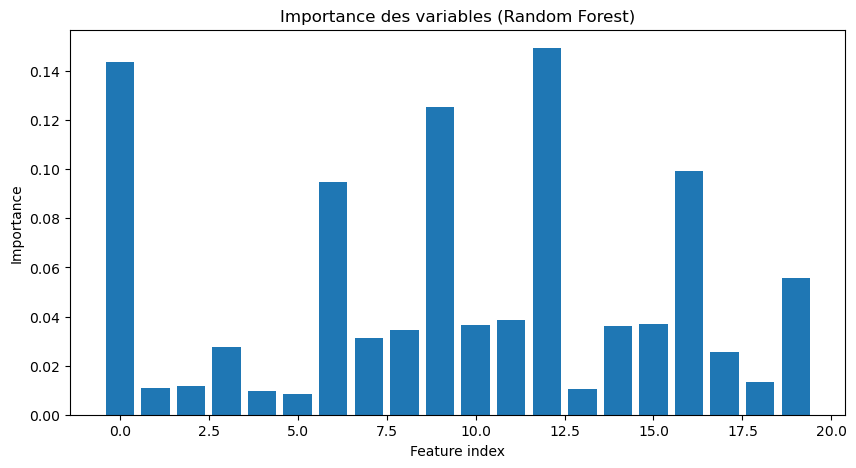

In [5]:
start = time.time()
rf = RandomForestClassifier(n_estimators=50, max_features='sqrt', random_state=42)
rf.fit(X_train, y_train)
elapsed_rf = time.time() - start

rf_acc = accuracy_score(y_test, rf.predict(X_test))

print(f"Random Forest Test Accuracy: {rf_acc:.3f}")
print(f"Temps d'entraînement: {elapsed_rf:.4f}s")

rf_times = {}
for mf in [1, 5, 10, 15, 20]:
    start = time.time()
    rf = RandomForestClassifier(n_estimators=50, max_features=mf, random_state=42)
    rf.fit(X_train, y_train)
    elapsed = time.time() - start
    rf_times[mf] = elapsed
    acc = accuracy_score(y_test, rf.predict(X_test))
    print(f"Random Forest Test Accuracy (max_features={mf}): {acc:.3f} | Temps d'entraînement: {elapsed:.4f}s")

importances = rf.feature_importances_
plt.figure(figsize=(10, 5))
plt.bar(range(len(importances)), importances)
plt.xlabel("Feature index")
plt.ylabel("Importance")
plt.title("Importance des variables (Random Forest)")
plt.show()

In [6]:
stump = DecisionTreeClassifier(max_depth=1)
adaboost_times = {}

for lr in [0.01, 0.1, 0.5, 1.0, 1.5]:
    start = time.time()
    ada = AdaBoostClassifier(estimator=stump, n_estimators=50, learning_rate=lr, random_state=42)
    ada.fit(X_train, y_train)
    elapsed = time.time() - start
    adaboost_times[lr] = elapsed
    acc = accuracy_score(y_test, ada.predict(X_test))
    print(f"AdaBoost Test Accuracy (learning_rate={lr}): {acc:.3f} | Temps d'entraînement: {elapsed:.4f}s")

elapsed_ada = adaboost_times[1.0]

AdaBoost Test Accuracy (learning_rate=0.01): 0.682 | Temps d'entraînement: 0.5739s
AdaBoost Test Accuracy (learning_rate=0.1): 0.784 | Temps d'entraînement: 0.5313s
AdaBoost Test Accuracy (learning_rate=0.5): 0.798 | Temps d'entraînement: 0.5298s
AdaBoost Test Accuracy (learning_rate=1.0): 0.812 | Temps d'entraînement: 0.5692s
AdaBoost Test Accuracy (learning_rate=1.5): 0.790 | Temps d'entraînement: 0.6394s


XGBoost Test Accuracy: 0.956
Temps d'entraînement: 0.36s


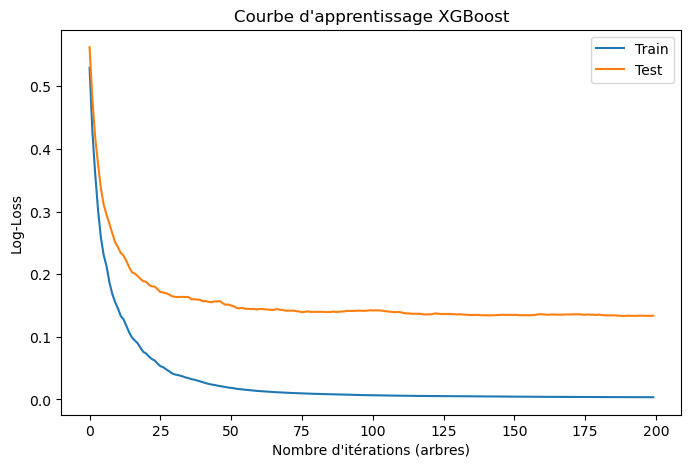

In [7]:
xgb = XGBClassifier(
    n_estimators=200,
    eval_metric='logloss',
    random_state=42
)

start = time.time()
xgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)
elapsed_xgb = time.time() - start

xgb_acc = accuracy_score(y_test, xgb.predict(X_test))
print(f"XGBoost Test Accuracy: {xgb_acc:.3f}")
print(f"Temps d'entraînement: {elapsed_xgb:.2f}s")

results = xgb.evals_result()
plt.figure(figsize=(8, 5))
plt.plot(results['validation_0']['logloss'], label='Train')
plt.plot(results['validation_1']['logloss'], label='Test')
plt.xlabel("Nombre d'itérations (arbres)")
plt.ylabel("Log-Loss")
plt.title("Courbe d'apprentissage XGBoost")
plt.legend()
plt.show()

In [8]:
log_reg = LogisticRegression(max_iter=1000)
svm = SVC(probability=True)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
xbg = XGBClassifier(eval_metric='logloss', random_state=42)

estimators = [
    ('log_reg', log_reg),
    ('svm', svm),
    ('rf', rf),
    ('xbg', xbg)
]

#@@@ Hard voting
start = time.time()
voting_hard = VotingClassifier(estimators=estimators, voting='hard')
voting_hard.fit(X_train, y_train)
elapsed_hard = time.time() - start
acc_hard = accuracy_score(y_test, voting_hard.predict(X_test))
print(f"Hard Voting Accuracy: {acc_hard:.3f}")
print(f"Temps d'entraînement (Hard Voting): {elapsed_hard:.4f}s")

#@@@ Soft voting
start = time.time()
voting_soft = VotingClassifier(estimators=estimators, voting='soft')
voting_soft.fit(X_train, y_train)
elapsed_soft = time.time() - start
acc_soft = accuracy_score(y_test, voting_soft.predict(X_test))
print(f"Soft Voting Accuracy: {acc_soft:.3f}")
print(f"Temps d'entraînement (Soft Voting): {elapsed_soft:.4f}s")

Hard Voting Accuracy: 0.952
Temps d'entraînement (Hard Voting): 1.7885s
Soft Voting Accuracy: 0.966
Temps d'entraînement (Soft Voting): 1.6734s


In [9]:
estimators_stack = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('svm', SVC(probability=True)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgb', XGBClassifier(eval_metric='logloss', random_state=42))
]

meta_model = LogisticRegression(max_iter=1000)

stacking = StackingClassifier(
    estimators=estimators_stack,
    final_estimator=meta_model,
    cv=5 
)

start = time.time()
stacking.fit(X_train, y_train)
elapsed_stacking = time.time() - start
acc_stacking = accuracy_score(y_test, stacking.predict(X_test))
print(f"Stacking Accuracy: {acc_stacking:.3f}")
print(f"Temps d'entraînement: {elapsed_stacking:.4f}s")

Stacking Accuracy: 0.962
Temps d'entraînement: 9.2508s


## Comparaison des temps d'entraînement

Temps d'entraînement par modèle :
  Decision Tree        : 0.0736s
  Bagging (manuel)     : 2.4860s
  Random Forest        : 0.6119s
  AdaBoost             : 0.5692s
  XGBoost              : 0.3563s
  Voting (Hard)        : 1.7885s
  Voting (Soft)        : 1.6734s
  Stacking             : 9.2508s


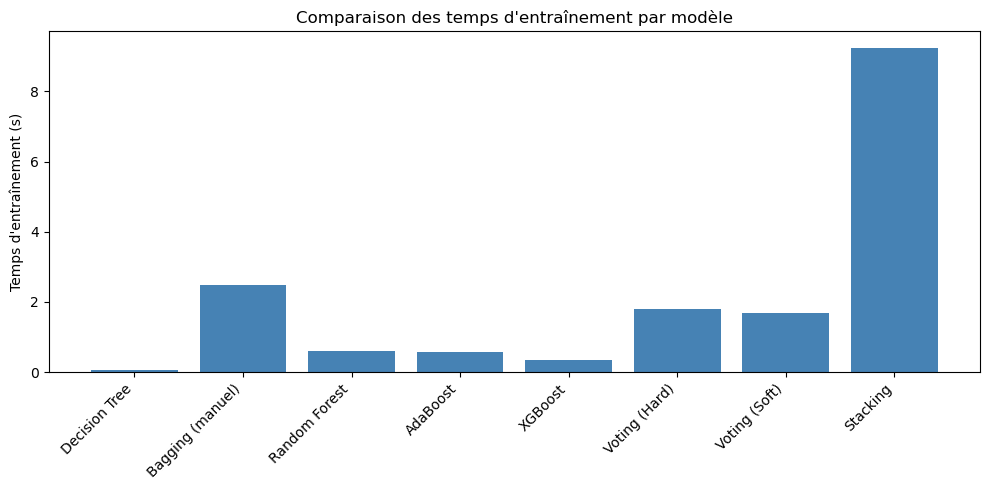

In [10]:
model_times = {
    "Decision Tree": elapsed_tree,
    "Bagging (manuel)": elapsed_bagging,
    "Random Forest": elapsed_rf,
    "AdaBoost": elapsed_ada,
    "XGBoost": elapsed_xgb,
    "Voting (Hard)": elapsed_hard,
    "Voting (Soft)": elapsed_soft,
    "Stacking": elapsed_stacking,
}

print("Temps d'entraînement par modèle :")
for name, t in model_times.items():
    print(f"  {name:20s} : {t:.4f}s")

plt.figure(figsize=(10, 5))
plt.bar(model_times.keys(), model_times.values(), color='steelblue')
plt.ylabel("Temps d'entraînement (s)")
plt.title("Comparaison des temps d'entraînement par modèle")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()